# Task 2 — Data Cleaning & Preprocessing 

**Goal:** Transform raw, messy data into a clean, analysis-ready dataset.

**Real Data Scientist Mindset:**
> Cleaning is not just removing bad rows.
> It means understanding *why* data looks the way it does
> and making deliberate, documented decisions about each issue.

**What we'll do:**
1. Standardise string formatting
2. Remove duplicates
3. Handle missing values
4. Flag dropout students
5. Encode categorical columns
6. Cap outliers
7. Engineer new features
8. Add target column
9. Save cleaned dataset

## Add src/ to path so we can import our module

In [7]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src/ to path so we can import our module
sys.path.append('..')
import src.data_cleaning as data_cleaning
importlib.reload(data_cleaning)
from src.data_cleaning import (
    load_raw_data, clean_data, get_cleaning_summary,
    scale_features, BINARY_COLS, MULTI_CAT_COLS
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Imports ready........................")

Imports ready........................


## Load raw data

In [8]:
df_raw = load_raw_data('../data/raw/student-mat.csv')

print(f"\nRaw data shape  : {df_raw.shape}")
print(f"Missing values  : {df_raw.isnull().sum().sum()}")
print(f"Duplicate rows  : {df_raw.duplicated().sum()}")
print(f"\nData types:")
print(df_raw.dtypes.value_counts())


Raw data loaded: 395 rows x 33 columns

Raw data shape  : (395, 33)
Missing values  : 0
Duplicate rows  : 0

Data types:
object    17
int64     16
Name: count, dtype: int64


## Before snapshot (document the raw state)

In [9]:
print(" RAW DATA SNAPSHOT ")
print(f"\nString columns ({len([col for col in df_raw.columns if pd.api.types.is_string_dtype(df_raw[col].dtype)])}):")
print([col for col in df_raw.columns if pd.api.types.is_string_dtype(df_raw[col].dtype)])

print(f"\nSample raw values to show why cleaning is needed:")
print(f"  school  : {df_raw['school'].unique()}  ← will lowercase")
print(f"  schoolsup: {df_raw['schoolsup'].unique()}  ← will encode to 0/1")
print(f"  sex     : {df_raw['sex'].unique()}  ← will label encode")
print(f"  absences max: {df_raw['absences'].max()}  ← will cap outlier")
print(f"  G3=0 students: {(df_raw['G3']==0).sum()}  ← will flag dropouts")

 RAW DATA SNAPSHOT 

String columns (17):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Sample raw values to show why cleaning is needed:
  school  : ['GP' 'MS']  ← will lowercase
  schoolsup: ['yes' 'no']  ← will encode to 0/1
  sex     : ['F' 'M']  ← will label encode
  absences max: 75  ← will cap outlier
  G3=0 students: 38  ← will flag dropouts


#  Run the full cleaning pipeline 
## This calls clean_data() from src/data_cleaning.py
## which runs all 9 steps in the correct order

In [10]:
df_clean = clean_data(df_raw)


 Starting data cleaning pipeline...
--------------------------------------------------
Standardised 17 string columns (strip + lowercase)
No duplicates found
No missing values found — nothing to fill
Flagged 13 likely dropout students (G2=0 & G3=0) -> 'is_dropout' column
Encoded 8 binary columns (yes->1, no->0)
Label encoded 9 categorical columns
Absences capped: 75 -> 18.299999999999955 (95th percentile)
Created 3 new features: parent_edu_avg, alc_total, grade_avg_g1g2
Target column 'pass_fail' added
     Pass: 265 (67.1%)  |  Fail: 130 (32.9%)
--------------------------------------------------
Cleaning complete: 395 rows x 38 columns


## After snapshot (verify cleaning worked)

In [11]:
print(" CLEANED DATA SNAPSHOT ")

print(f"\nShape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"All numeric: {all(df_clean.dtypes != 'object')}")

print(f"\nNew columns added:")
new_cols = ['is_dropout', 'pass_fail', 'parent_edu_avg', 'alc_total', 'grade_avg_g1g2']
for col in new_cols:
    print(f"  {col:<18}: {df_clean[col].describe().to_dict()}")

print(f"\nEncoded binary columns (should be 0 or 1 only):")
for col in BINARY_COLS:
    unique_vals = sorted(df_clean[col].unique().tolist())
    print(f"  {col:<12}: {unique_vals}")


 CLEANED DATA SNAPSHOT 

Shape: (395, 38)
Missing values: 0
All numeric: True

New columns added:
  is_dropout        : {'count': 395.0, 'mean': 0.03291139240506329, 'std': 0.17863094628704887, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 1.0}
  pass_fail         : {'count': 395.0, 'mean': 0.6708860759493671, 'std': 0.47048735363719635, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 1.0, 'max': 1.0}
  parent_edu_avg    : {'count': 395.0, 'mean': 2.6354430379746834, 'std': 0.9833690631633103, 'min': 0.5, '25%': 2.0, '50%': 2.5, '75%': 3.5, 'max': 4.0}
  alc_total         : {'count': 395.0, 'mean': 3.7721518987341773, 'std': 1.9843893758892999, 'min': 2.0, '25%': 2.0, '50%': 3.0, '75%': 5.0, 'max': 10.0}
  grade_avg_g1g2    : {'count': 395.0, 'mean': 10.811392405063291, 'std': 3.4074786122345024, 'min': 2.0, '25%': 8.5, '50%': 11.0, '75%': 13.0, 'max': 19.0}

Encoded binary columns (should be 0 or 1 only):
  schoolsup   : [0, 1]
  famsup      : [0, 1]
  paid        : [0, 1]
  activ

## Visualise the encoding changes

In [10]:
!pip install matplotlib

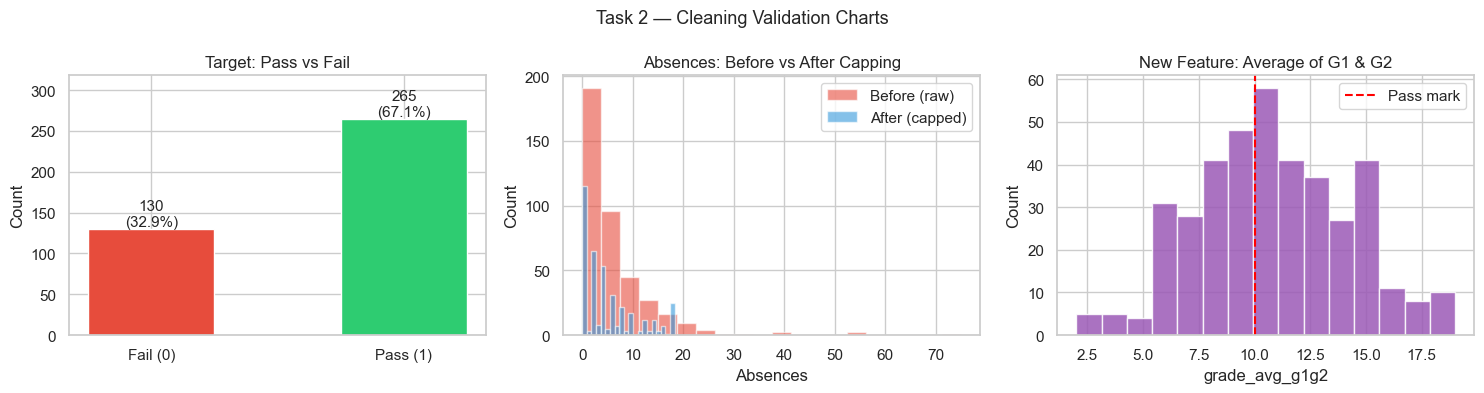

Chart saved to images/charts/task2_cleaning_validation.png
── DROPOUT STUDENTS (G2=0 AND G3=0) ────────────────────────────────────

Total flagged: 13 students

Their G1 scores (they performed before dropping out):
     G1  G2  G3  absences  failures  is_dropout
130  12   0   0       0.0         2           1
131   8   0   0       0.0         0           1
134   9   0   0       0.0         0           1
135  11   0   0       0.0         0           1
136  10   0   0       0.0         0           1
137   4   0   0       0.0         2           1
144   5   0   0       0.0         3           1
153   5   0   0       0.0         3           1
162   7   0   0       0.0         1           1
242   6   0   0       0.0         0           1
244   7   0   0       0.0         0           1
269   6   0   0       0.0         0           1
332   7   0   0       0.0         0           1

 Insight: These students are kept in the dataset.
   The model can learn from their early signals (G1, absences,

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#  Plot 1: Pass/Fail balance 
pass_counts = df_clean['pass_fail'].value_counts().sort_index()
axes[0].bar(['Fail (0)', 'Pass (1)'], pass_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, v in enumerate(pass_counts.values):
    axes[0].text(i, v + 3, f'{v}\n({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Target: Pass vs Fail')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(pass_counts.values) * 1.2)

#  Plot 2: Absences before vs after capping 
axes[1].hist(df_raw['absences'], bins=20, alpha=0.6, color='#e74c3c',
             edgecolor='white', label='Before (raw)')
axes[1].hist(df_clean['absences'], bins=20, alpha=0.6, color='#3498db',
             edgecolor='white', label='After (capped)')
axes[1].set_title('Absences: Before vs After Capping')
axes[1].set_xlabel('Absences')
axes[1].set_ylabel('Count')
axes[1].legend()

#  Plot 3: New feature — grade_avg_g1g2 distribution 
axes[2].hist(df_clean['grade_avg_g1g2'], bins=15, color='#9b59b6',
             edgecolor='white', alpha=0.85)
axes[2].axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Pass mark')
axes[2].set_title('New Feature: Average of G1 & G2')
axes[2].set_xlabel('grade_avg_g1g2')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Task 2 — Cleaning Validation Charts', fontsize=13)
plt.tight_layout()
os.makedirs('../images/charts', exist_ok=True)
plt.savefig('../images/charts/task2_cleaning_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/charts/task2_cleaning_validation.png")


# ── CELL 8 ── Check the dropout students ─────────────────────────────────────
print("── DROPOUT STUDENTS (G2=0 AND G3=0) ────────────────────────────────────")
dropouts = df_clean[df_clean['is_dropout'] == 1]
print(f"\nTotal flagged: {len(dropouts)} students")
print(f"\nTheir G1 scores (they performed before dropping out):")
print(dropouts[['G1', 'G2', 'G3', 'absences', 'failures', 'is_dropout']].to_string())
print(f"\n Insight: These students are kept in the dataset.")
print(f"   The model can learn from their early signals (G1, absences, failures).")


### Create scaled version for model use 
### NOTE: We keep df_clean unscaled for EDA (Task 3 & 4)
###       We use df_scaled only when training the model (Task 5)


In [13]:
df_scaled, scaler = scale_features(df_clean)

print(f"\ndf_clean  → unscaled → use for EDA and visualisation")
print(f"df_scaled → scaled   → use for model training")
print(f"\nSample scaled values (should be near 0, mostly between -3 and 3):")
print(df_scaled[['age', 'absences', 'G1', 'G2', 'grade_avg_g1g2']].describe().round(3))

Scaled 13 numerical features (mean=0, std=1)

df_clean  → unscaled → use for EDA and visualisation
df_scaled → scaled   → use for model training

Sample scaled values (should be near 0, mostly between -3 and 3):
           age  absences       G1       G2  grade_avg_g1g2
count  395.000   395.000  395.000  395.000         395.000
mean     0.000    -0.000    0.000   -0.000           0.000
std      1.001     1.001    1.001    1.001           1.001
min     -1.331    -0.932   -2.386   -2.852          -2.589
25%     -0.546    -0.932   -0.877   -0.456          -0.679
50%      0.238    -0.202    0.027    0.076           0.055
75%      1.023     0.529    0.631    0.609           0.643
max      4.162     2.409    2.441    2.206           2.406


# Save cleaned data 

In [14]:

os.makedirs('../data/processed', exist_ok=True)

# Unscaled version — for EDA
df_clean.to_csv('../data/processed/student_clean.csv', index=False)

# Scaled version — for model
df_scaled.to_csv('../data/processed/student_scaled.csv', index=False)

print("Files saved:")
print("   data/processed/student_clean.csv   ← use for EDA (Tasks 3 & 4)")
print("   data/processed/student_scaled.csv  ← use for Model (Task 5)")
print(f"\n   student_clean.csv  : {df_clean.shape}")
print(f"   student_scaled.csv : {df_scaled.shape}")

Files saved:
   data/processed/student_clean.csv   ← use for EDA (Tasks 3 & 4)
   data/processed/student_scaled.csv  ← use for Model (Task 5)

   student_clean.csv  : (395, 38)
   student_scaled.csv : (395, 38)


In [15]:
# Summary 
get_cleaning_summary(df_raw, df_clean)


  TASK 2 SUMMARY — Data Cleaning & Preprocessing

  Before cleaning
    Shape          : 395 rows × 33 columns
    Missing values : 0
    Duplicates     : 0
    String columns : 17

  After cleaning
    Shape          : 395 rows × 38 columns
    Missing values : 0
    All numeric    : True
    New features   : parent_edu_avg, alc_total, grade_avg_g1g2
    New columns    : is_dropout, pass_fail

  Encoding applied
    Binary (yes/no): yes→1, no→0  (8 columns)
    Label encoded  : school, sex, address, famsize, Pstatus,
                     Mjob, Fjob, reason, guardian

  Outlier treatment
    absences       : capped at 95th percentile

  Target variable
    pass_fail      : 265 pass | 130 fail

